In [36]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 固定写法
# --- 显示设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei']   # 中文字体（如环境无该字体，可改为 'Microsoft YaHei'）
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f"{x:,.6f}")

DATA_DIR = Path("D:/Code Files/四六级/学习部署/data")
RAW_FILE = DATA_DIR / "sample_users.csv"

print("RAW_FILE =", RAW_FILE)

RAW_FILE = D:\Code Files\四六级\学习部署\data\sample_users.csv


## 1. 数据探索与清洗

In [37]:
data = pd.read_csv(
    RAW_FILE,
    index_col=0,
    dtype={"category_id": "int64", "user_id": "int64"},
    encoding="utf-8",
)

data.head(2)

,testSub,uname,idCard,schoolName,reportNum,examNum,totalScore,listening,reading,writing,speakingExamNum,speakingScore
No.,,,,,,,,,,,,
1,全国大学英语六级考试(CET6),张三,410115200020130025,北京大学,251121028000922,20260101,450,150,150,150,--,--
2,全国大学英语六级考试(CET6),李勤阳,650115200020130028,东北师范大学,251121028000922,220020252210520,410,123,157,130,--,--


### 查看缺失值

In [38]:
data.shape

(41, 12)

In [39]:
data.info(show_counts=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 1 to 41
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   testSub          41 non-null     object
 1   uname            41 non-null     object
 2   idCard           41 non-null     object
 3   schoolName       41 non-null     object
 4   reportNum        41 non-null     int64 
 5   examNum          41 non-null     int64 
 6   totalScore       41 non-null     int64 
 7   listening        41 non-null     int64 
 8   reading          41 non-null     int64 
 9   writing          41 non-null     int64 
 10  speakingExamNum  41 non-null     object
 11  speakingScore    41 non-null     object
dtypes: int64(6), object(6)
memory usage: 4.2+ KB


In [40]:
data.isnull().sum()

testSub            0
uname              0
idCard             0
schoolName         0
reportNum          0
examNum            0
totalScore         0
listening          0
reading            0
writing            0
speakingExamNum    0
speakingScore      0
dtype: int64

### 1.2 查看重复值

In [41]:
data.duplicated().sum()

np.int64(0)

In [42]:
# 查看有哪些重复值
data.value_counts().reset_index().sort_values(by='count', ascending=False).head()

,testSub,uname,idCard,schoolName,reportNum,examNum,totalScore,listening,reading,writing,speakingExamNum,speakingScore,count
0,全国大学英语六级考试(CET6),佘昱杭,421723200406120043,中南财经政法大学,252252009000495,420041252230028,519,155,195,169,--,--,1
1,全国大学英语六级考试(CET6),倪雅兰,510115200020130824,广东药科大学,251121028000922,440950252213921,453,133,184,136,--,--,1
2,全国大学英语六级考试(CET6),刘慧婷,362430200405137823,广东东软学院,252244085001079,440850252204606,430,124,150,156,--,--,1
3,全国大学英语六级考试(CET6),周瑾芸,430115200020130043,长沙医学院,252143033003945,430331252120124,463,151,167,145,--,--,1
4,全国大学英语六级考试(CET6),姜申睿,610430200405137521,洛阳理工学院,411542272209524,411542252209524,456,177,167,112,--,--,1


In [43]:
# 查看姓名和准考证号是否有重复
data[['uname', 'examNum']].duplicated().sum()


np.int64(0)

In [44]:
# 查看字段reportNum是否有重复值
data['reportNum'].duplicated().sum()

np.int64(29)

In [45]:
# 查看reportNum重复值的详情
data[data['reportNum'].duplicated()].sort_values(by='reportNum').head(3)

,testSub,uname,idCard,schoolName,reportNum,examNum,totalScore,listening,reading,writing,speakingExamNum,speakingScore
No.,,,,,,,,,,,,
2,全国大学英语六级考试(CET6),李勤阳,650115200020130028,东北师范大学,251121028000922,220020252210520,410,123,157,130,--,--
3,全国大学英语六级考试(CET6),郭昱瑶,150121200211080945,四川大学,251121028000922,510011252100504,517,164,193,160,--,--
4,全国大学英语六级考试(CET6),倪雅兰,510115200020130824,广东药科大学,251121028000922,440950252213921,453,133,184,136,--,--


### 1.3 查看异常数据

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 1 to 41
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   testSub          41 non-null     object
 1   uname            41 non-null     object
 2   idCard           41 non-null     object
 3   schoolName       41 non-null     object
 4   reportNum        41 non-null     int64 
 5   examNum          41 non-null     int64 
 6   totalScore       41 non-null     int64 
 7   listening        41 non-null     int64 
 8   reading          41 non-null     int64 
 9   writing          41 non-null     int64 
 10  speakingExamNum  41 non-null     object
 11  speakingScore    41 non-null     object
dtypes: int64(6), object(6)
memory usage: 4.2+ KB


In [47]:
data.describe(percentiles=[0.01,0.25,0.75,0.99], include='all').T

,count,unique,top,freq,mean,std,min,1%,25%,50%,75%,99%,max
testSub,41,2,全国大学英语六级考试(CET6),26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uname,41,40,戴颖洁,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idCard,41,40,451723200406120028,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
schoolName,41,37,浙大宁波理工学院,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reportNum,41.000000,NaN,NaN,NaN,"263,808,977,723,940.875000","42,042,963,496,325.585938","251,121,028,000,922.000000","251,121,028,000,922.000000","252,143,033,003,945.000000","252,244,085,001,079.000000","252,252,009,000,495.000000","411,542,272,209,524.000000","411,542,272,209,524.000000"
examNum,41.000000,NaN,NaN,NaN,"361,117,196,244,296.875000","157,562,583,228,585.781250","20,260,101.000000","10,012,343,108,836.201172","220,020,252,210,580.000000","360,091,252,213,328.000000","451,081,252,117,429.000000","610,150,855,744,730.625000","610,171,252,100,607.000000"
totalScore,41.000000,NaN,NaN,NaN,460.853659,52.765785,410.000000,412.800000,428.000000,435.000000,476.000000,631.600000,652.000000
listening,41.000000,NaN,NaN,NaN,144.243902,21.398342,122.000000,122.400000,126.000000,140.000000,151.000000,208.200000,215.000000
reading,41.000000,NaN,NaN,NaN,175.487805,31.589652,128.000000,133.200000,153.000000,167.000000,189.000000,268.200000,291.000000
writing,41.000000,NaN,NaN,NaN,143.658537,23.041929,112.000000,112.000000,127.000000,141.000000,152.000000,202.200000,203.000000


## 2. 数据分析

### 2.1 性别比例统计

In [48]:
# 根据身份证号倒数第二位判断性别（奇数为男，偶数为女）
def get_gender(id_card):
    second_last = str(id_card)[-2]
    return '男性' if int(second_last) % 2 == 1 else '女性'

# 统计性别比例
data['gender'] = data['idCard'].apply(get_gender)
gender_counts = data['gender'].value_counts()

print("性别比例统计：")
print(gender_counts)
print(f"\n男性占比：{gender_counts['男性'] / len(data) * 100:.1f}%")
print(f"女性占比：{gender_counts['女性'] / len(data) * 100:.1f}%")

性别比例统计：
gender
女性    33
男性     8
Name: count, dtype: int64

男性占比：19.5%
女性占比：80.5%


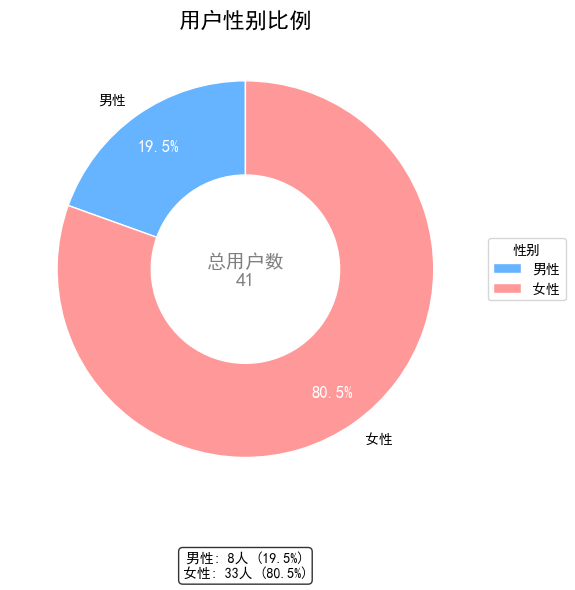

In [49]:
# ==================== 绘制性别比例环形图 ====================

# 准备图表需要的标签数据：设置饼图的分类名称
labels = ['男性', '女性']

# 准备图表数值：从统计结果中获取男性、女性数量（没有则取0）
sizes = [gender_counts.get('男性', 0), gender_counts.get('女性', 0)]

# 设置颜色：男性蓝色、女性粉色
colors = ['#66b3ff', '#ff9999']

# 创建画布和坐标系：设置图形大小为 6x6（正方形，保证饼图是正圆形），像素为100
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# 绘制环形图（核心绘图函数）
wedges, texts, autotexts = ax.pie(
    sizes,                # 传入数据（男、女人数）
    labels=labels,        # 传入分类标签
    colors=colors,        # 传入自定义颜色
    autopct='%.1f%%',     # 显示百分比格式（保留1位小数）
    startangle=90,        # 饼图起始角度（90度=从正上方开始）
    pctdistance=0.80,     # 百分比文字距离中心的距离
    wedgeprops=dict(width=0.5, edgecolor='white')  # 环形宽度+白色边框
)

# 循环设置所有百分比标签的样式
for autotext in autotexts:
    autotext.set_fontsize(12)      # 字体大小12号
    autotext.set_color('white')    # 字体颜色白色
    autotext.set_weight('bold')    # 字体加粗
    autotext.set_ha('center')      # 水平居中对齐

# ==================== 优化1：添加总用户数标签 ====================
# 计算总用户数：将男性用户数和女性用户数相加
total_users = sum(sizes)  # sizes数组包含男性和女性用户数量
# 在饼图中心位置添加总用户数标签
ax.text(
    0, 0,                        # 文本位置：饼图中心点（坐标原点）
    f'总用户数\n{total_users}',  # 文本内容：显示总用户数，使用换行符分隔
    ha='center',                 # 水平对齐方式：居中对齐
    va='center',                 # 垂直对齐方式：居中对齐
    fontsize=14,                 # 字体大小：14号，比百分比标签稍大
    fontweight='bold',           # 字体样式：加粗显示
    color='gray'                 # 字体颜色：灰色，避免与饼图颜色冲突
)

# ==================== 优化2：添加统计摘要 ====================
# 计算男性用户百分比：男性用户数除以总用户数，乘以100，保留1位小数
male_percentage = sizes[0] / total_users * 100
# 计算女性用户百分比：女性用户数除以总用户数，乘以100，保留1位小数
female_percentage = sizes[1] / total_users * 100
# 创建统计摘要文本：包含详细的数量和百分比信息
summary_text = f"男性: {sizes[0]}人 ({male_percentage:.1f}%)\n女性: {sizes[1]}人 ({female_percentage:.1f}%)"
# 在图表下方添加统计摘要文本
ax.text(
    0.5,                        # X坐标：图表中间位置（相对坐标系）
    -0.1,                       # Y坐标：图表下方（相对坐标系）
    summary_text,               # 文本内容：统计摘要信息
    transform=ax.transAxes,     # 使用相对坐标系转换
    ha='center',                # 水平对齐方式：居中对齐
    va='top',                   # 垂直对齐方式：顶部对齐
    fontsize=10,                # 字体大小：10号，比中心标签稍小
    bbox=dict(                  # 添加背景框，提高文本可读性
        boxstyle="round,pad=0.3",  # 边框样式：圆角矩形，内边距0.3
        fc="white",               # 背景颜色：白色
        alpha=0.8                  # 背景透明度：80%，半透明效果
    )
)

# 设置图表大标题
ax.set_title(
    '用户性别比例',    # 标题文字
    fontsize=16,        # 标题字号
    fontweight='bold',  # 标题加粗
    pad=5               # 标题距离图表的间距
)

# 添加图例（右侧显示性别对应颜色）
ax.legend(
    wedges,             # 饼图色块
    labels,             # 性别名称
    title="性别",       # 图例标题
    loc="center left",  # 图例位置：中间左侧
    bbox_to_anchor=(1, 0, 0.5, 1)  # 把图例放到图表外面
)

# 自动调整布局，防止文字被截断
plt.tight_layout()

# 显示图表（弹出图片窗口）
plt.show()

### 2.2 省份地区分布统计

In [50]:
# ==================== 省份分布统计 ====================

# 身份证号前两位对应的省份映射
province_code_map = {
    '11': '北京市', '12': '天津市', '13': '河北省', '14': '山西省', '15': '内蒙古自治区',
    '21': '辽宁省', '22': '吉林省', '23': '黑龙江省',
    '31': '上海市', '32': '江苏省', '33': '浙江省', '34': '安徽省', '35': '福建省', '36': '江西省', '37': '山东省',
    '41': '河南省', '42': '湖北省', '43': '湖南省', '44': '广东省', '45': '广西壮族自治区', '46': '海南省',
    '50': '重庆市', '51': '四川省', '52': '贵州省', '53': '云南省', '54': '西藏自治区',
    '61': '陕西省', '62': '甘肃省', '63': '青海省', '64': '宁夏回族自治区', '65': '新疆维吾尔自治区',
    '71': '台湾省', '81': '香港特别行政区', '82': '澳门特别行政区'
}

# 根据身份证号前两位获取省份
def get_province(id_card):
    code = str(id_card)[:2]
    return province_code_map.get(code, '未知')

# 统计省份分布
data['province'] = data['idCard'].apply(get_province)
province_counts = data['province'].value_counts()

print("省份分布统计：")
print(province_counts)

省份分布统计：
province
江苏省         4
安徽省         4
四川省         3
内蒙古自治区      3
广东省         3
广西壮族自治区     3
江西省         3
河南省         2
甘肃省         2
陕西省         2
浙江省         2
重庆市         2
新疆维吾尔自治区    1
湖南省         1
辽宁省         1
西藏自治区       1
吉林省         1
湖北省         1
河北省         1
山东省         1
Name: count, dtype: int64


### 用户分布地图

共有 34 个省份/自治区/直辖市
有用户分布的省份：20 个
无用户分布的省份：14 个

地图数据字段：['adcode', 'name', 'adchar', 'center', 'centroid', 'childrenNum', 'level', 'parent', 'subFeatureIndex', 'acroutes', 'geometry']


c:\Users\17691\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'adcode' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


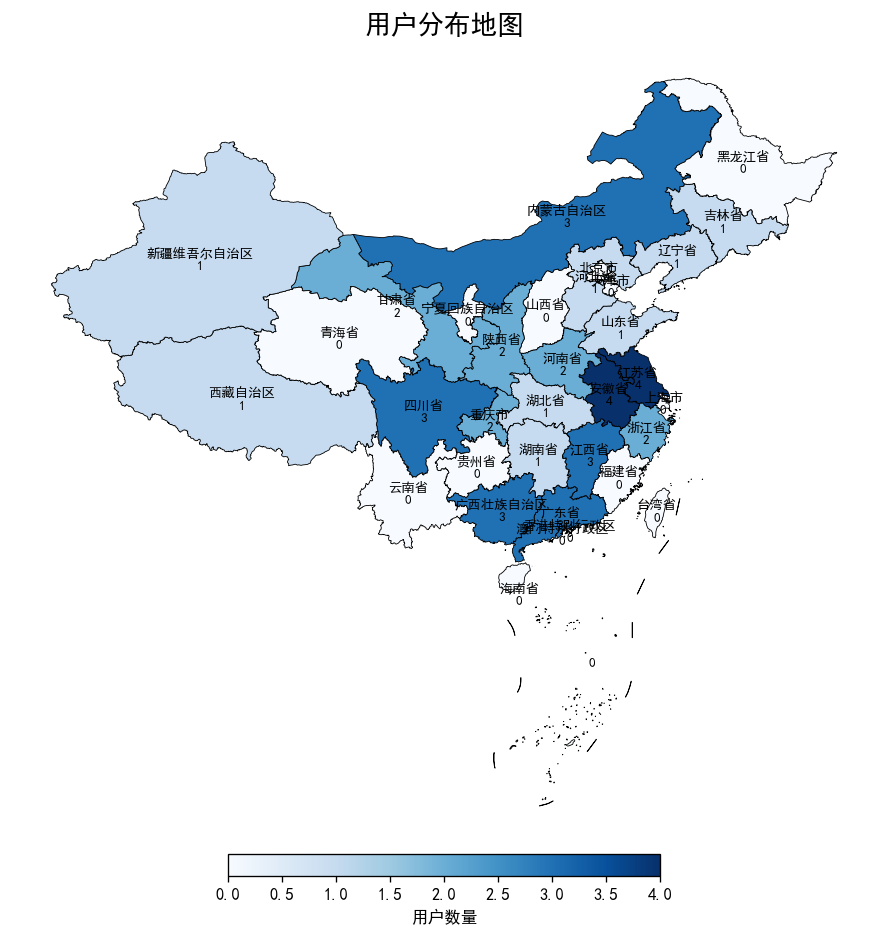

In [51]:
# ==================== 用户分布地图 ====================

# 异常捕获模块：尝试执行地图绘制相关代码，避免因库缺失/文件不存在导致程序崩溃
try:
    # 导入第三方地理数据处理库：geopandas（地图处理）、shapely（几何对象）
    import geopandas as gpd
    from shapely.geometry import Point
    
    # 获取完整的省份名称列表（从省份编码映射中提取）
    all_provinces = list(province_code_map.values())
    # 初始化所有省份用户数量为0，确保地图上所有省份都有数据
    province_user_count = {province: 0 for province in all_provinces}
    
    # 遍历统计好的省份用户数据，更新有用户的省份数量
    for province, count in province_counts.items():
        # 仅当省份名称在标准省份列表中时，才更新数量
        if province in province_user_count:
            province_user_count[province] = count
    
    # 通过字典推导式，将省份用户数量字典转换为DataFrame格式
    province_df = pd.DataFrame([
        {'province': province, 'user_count': count}
        for province, count in province_user_count.items()
    ])
    
    # 打印统计信息：总省份数量
    print(f"共有 {len(province_df)} 个省份/自治区/直辖市")
    # 打印：有用户分布的省份数量
    print(f"有用户分布的省份：{(province_df['user_count'] > 0).sum()} 个")
    # 打印：无用户分布的省份数量
    print(f"无用户分布的省份：{(province_df['user_count'] == 0).sum()} 个")
    
    # 定义中国地图GeoJSON文件的路径
    map_file = DATA_DIR / "china_provinces.json"
    
    # 判断地图文件是否存在，存在则执行地图绘制逻辑
    if map_file.exists():
        # 读取GeoJSON格式的中国省级地图数据
        china_map = gpd.read_file(map_file)
        
        # 打印地图数据包含的字段名称，用于调试和匹配字段
        print(f"\n地图数据字段：{list(china_map.columns)}")
        
        # 定义省份名称映射字典，保证数据合并时名称匹配
        province_name_map = {
            '北京市': '北京市', '天津市': '天津市', '河北省': '河北省', '山西省': '山西省',
            '内蒙古自治区': '内蒙古自治区', '辽宁省': '辽宁省', '吉林省': '吉林省',
            '黑龙江省': '黑龙江省', '上海市': '上海市', '江苏省': '江苏省',
            '浙江省': '浙江省', '安徽省': '安徽省', '福建省': '福建省',
            '江西省': '江西省', '山东省': '山东省', '河南省': '河南省',
            '湖北省': '湖北省', '湖南省': '湖南省', '广东省': '广东省',
            '广西壮族自治区': '广西壮族自治区', '海南省': '海南省', '重庆市': '重庆市',
            '四川省': '四川省', '贵州省': '贵州省', '云南省': '云南省',
            '西藏自治区': '西藏自治区', '陕西省': '陕西省', '甘肃省': '甘肃省',
            '青海省': '青海省', '宁夏回族自治区': '宁夏回族自治区',
            '新疆维吾尔自治区': '新疆维吾尔自治区', '台湾省': '台湾省',
            '香港特别行政区': '香港特别行政区', '澳门特别行政区': '澳门特别行政区'
        }
        
        # 合并地图数据与用户统计数据：左连接，保留所有地图省份
        china_map = china_map.merge(
            province_df,
            left_on='name',        # 地图数据的匹配字段
            right_on='province',   # 用户数据的匹配字段
            how='left'             # 左连接：以地图数据为准
        )
        
        # 将合并后缺失的用户数量填充为0，避免绘图报错
        china_map['user_count'] = china_map['user_count'].fillna(0)
        
        # 创建画布与坐标系：设置画布尺寸和分辨率
        fig, ax = plt.subplots(figsize=(7.5, 10), dpi=120)
        
        # 绘制分级设色地图：按用户数量着色
        china_map.plot(
            column='user_count',        # 依据用户数量列进行着色
            cmap='Blues',               # 配色方案：蓝色渐变
            linewidth=0.5,              # 省份边界线宽度
            edgecolor='black',          # 省份边界线颜色
            legend=True,                # 显示图例
            ax=ax,                      # 指定绘制的坐标系
            legend_kwds={               # 图例配置参数
                'label': '用户数量',    # 图例标题
                'orientation': 'horizontal',  # 图例水平摆放
                'shrink': 0.5,          # 图例缩放比例
                'pad': 0.01             # 图例与图表间距
            }
        )
        
        # 遍历每一行地图数据，为每个省份添加文本标签
        for idx, row in china_map.iterrows():
            # 获取当前省份几何图形的中心点坐标
            centroid = row.geometry.centroid
            # 获取省份名称：优先使用用户数据中的名称，无则使用地图自带名称
            province_name = row['province'] if pd.notna(row.get('province')) else row.get('name', '')
            # 获取当前省份的用户数量并转为整数
            user_count = int(row['user_count'])
            
            # 在省份中心点位置添加文本标签（省份名+用户数）
            ax.text(
                centroid.x,             # 标签X坐标（中心点X）
                centroid.y,             # 标签Y坐标（中心点Y）
                f"{province_name}\n{user_count}",  # 标签内容
                fontsize=8,             # 字体大小
                color='black',          # 字体颜色
                weight='bold',          # 字体加粗
                ha='center',            # 水平居中
                va='center'             # 垂直居中
            )
        
        # 设置地图总标题
        ax.set_title('用户分布地图', fontsize=16, fontweight='bold', pad=5)
        # 设置坐标系背景色为白色
        ax.set_facecolor('white')
        # 关闭坐标轴显示（地图不需要坐标轴）
        ax.axis('off')
        
        # 自动调整图表布局，防止文字被截断
        plt.tight_layout()
        # 显示绘制完成的地图图表
        plt.show()
    # 如果地图文件不存在，执行以下替代方案（绘制条形图）
    else:
        # 打印提示信息：地图文件不存在
        print(f"\n地图文件不存在：{map_file}")
        # 打印提示信息：告知用户文件存放位置
        print("请下载中国地图GeoJSON文件并放在data目录下")
        # 打印提示信息：说明当前将采用临时方案（条形图）
        print("\n临时方案：使用条形图展示省份分布")
        
        # 创建画布和坐标系，设置图表尺寸为12x8
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # 筛选出用户数量大于0的省份数据，并按用户数量升序排列
        province_with_users = province_df[province_df['user_count'] > 0].sort_values('user_count', ascending=True)
        
        # 绘制水平条形图，X轴为用户数量，Y轴为省份名称
        bars = ax.barh(
            province_with_users['province'],       # Y轴数据：省份名称
            province_with_users['user_count'],     # X轴数据：用户数量
            color='steelblue'                      # 条形颜色：钢蓝色
        )
        
        # 遍历所有条形，为每个条形添加数值标签
        for bar in bars:
            # 获取条形的长度（即用户数量值）
            width = bar.get_width()
            # 在条形末端添加文本标签
            ax.text(
                width + 0.1,                        # 标签X坐标：条形末端右侧偏移0.1
                bar.get_y() + bar.get_height() / 2, # 标签Y坐标：条形垂直居中
                f'{int(width)}',                    # 标签显示内容：用户数量（转为整数）
                ha='left',                          # 水平对齐方式：左对齐
                va='center',                        # 垂直对齐方式：居中
                fontsize=10,                        # 字体大小
                fontweight='bold'                   # 字体加粗
            )
        
        # 设置X轴标题
        ax.set_xlabel('用户数量', fontsize=12, fontweight='bold')
        # 设置Y轴标题
        ax.set_ylabel('省份', fontsize=12, fontweight='bold')
        # 设置图表总标题，设置字体大小、加粗、间距
        ax.set_title('用户省份分布统计', fontsize=16, fontweight='bold', pad=20)
        # 添加X轴方向的网格线，设置透明度
        ax.grid(axis='x', alpha=0.3)
        
        # 自动调整子图布局，防止标签重叠
        plt.tight_layout()
        # 显示绘制好的条形图
        plt.show()

# 捕获导入库失败的异常（geopandas或shapely未安装）
except ImportError:
    # 打印提示信息：缺少必要的库
    print("缺少必要的库，请安装：pip install geopandas shapely")
    # 打印提示信息：将使用基础条形图展示
    print("\n使用基础条形图展示省份分布")
    
    # 创建画布和坐标系，设置图表尺寸为12x8
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 将省份统计数据转为DataFrame，并按用户数量升序排列
    province_with_users = pd.DataFrame({
        'province': province_counts.index,      # 省份名称列
        'user_count': province_counts.values    # 用户数量列
    }).sort_values('user_count', ascending=True)
    
    # 绘制水平条形图
    bars = ax.barh(
        province_with_users['province'],       # Y轴：省份
        province_with_users['user_count'],     # X轴：用户数量
        color='steelblue'                      # 条形颜色
    )
    
    # 为每个条形添加数值标签
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f'{int(width)}',
            ha='left',
            va='center',
            fontsize=10,
            fontweight='bold'
        )
    
    # 设置X轴标签
    ax.set_xlabel('用户数量', fontsize=12, fontweight='bold')
    # 设置Y轴标签
    ax.set_ylabel('省份', fontsize=12, fontweight='bold')
    # 设置图表标题
    ax.set_title('用户省份分布统计', fontsize=16, fontweight='bold', pad=20)
    # 添加横向网格线
    ax.grid(axis='x', alpha=0.3)
    
    # 自动调整布局
    plt.tight_layout()
    # 显示图表
    plt.show()